# 🧪 LAB: Non-linear Dimensionality Reduction — t-SNE and UMAP

Over the past few weeks, we have explored how to handle **non-linear relationships**, mainly in the context of **classification and regression** tasks.

However, sometimes the first and most important step is to **visualize** the data — to gain intuition, spot structure, or detect outliers — even before any predictive modeling. You have already seen how **PCA** can help with this, but as we discussed this week, PCA is a **linear method** and may not capture non-linear patterns in the data effectively.

In this lab, you will learn about two popular **non-linear dimensionality reduction techniques** that are particularly useful for **data visualization**:  
- **t-SNE (t-distributed Stochastic Neighbor Embedding)**  
- **UMAP (Uniform Manifold Approximation and Projection)**

You will apply and compare these methods on two datasets:
- A simple biological dataset: **Palmer Penguins**
- A high-dimensional human genotype dataset from the **1000 Genomes Project** (adapted from Diaz-Papkovich *et al.*, 2019)

---

**Collaboration Note**: This assignment is designed to support collaborative work. We encourage you to divide tasks among group members so that everyone can contribute meaningfully. Many components of the assignment can be approached in parallel or split logically across team members. Good coordination and thoughtful integration of your work will lead to a stronger final result.

---

In total, this lab assignment will be worth **100 points**.

---
**Submission notes**:

* Write down all group members' names, or at least the group name (if you have one and you previously provided it), in the first cell of the notebook.

* Verify that the notebook runs as expected and that all required outputs are included.


In [ ]:
# NAME(s) = "DJ, Kayla, Mason"

Name(s) = "DJ, Kayla, Mason

In [1]:
# Imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

## 1. Background Reading (20 points) (Kayla)

Begin by reading **Section 5.3: t-SNE and UMAP for High-Dimensional Data** from the [*Machine Learning Hero* book](https://www.oreilly.com/library/view/machine-learning-hero/9781837025015/), which is available through UVA’s subscription to O’Reilly.

After reading, discuss with your group and respond to the following questions:

a. **Why might we choose t-SNE or UMAP over PCA for dimensionality reduction?**  
Briefly explain the limitations of PCA, and why non-linear methods like t-SNE and UMAP can be more effective in some contexts.

- PCA works well as a linear dimensionality reduction technique, but is poorer than t-SNE or UMAP when it comes to preserving the local structure of non-linear data. The PCA may also create spreads between points that were once closer together. t-SNE and UMAP work to preserve these relationships and distances between points and reveal patterns (clusters/manifolds) found in the original high-dimensional data.

______

b. **Summarize the strengths and weaknesses of t-SNE and UMAP.**  
What are the key differences between the two methods? In what situations might you prefer one over the other?

- Strengths of t-SNE include that t-SNE works well to capture complex, non-linear relationships in high-dimensional data (clusters, manifolds, outliers), and is a great visualization tool in 2D or 3D representations. Weaknesses of t-SNE include how there's a time complexity of $O(n^2)$, it may have random outputs that aren't always the same despite same parameters, and the the model may preserve local but non-global structures.

- Strengths of UMAP include preservation of global and local structures,  computationally efficient, and versatility to different types of data (categorical, numerical, etc.). A weakness is that the UMAP is very sensitive to the hyperparameters of n_neighbors and min_dist.

- One might prefer t-SNE when looking to discover more local compared to encapsulating global patterns within a dataset. The UMAP may be more preferred when there exists a larger dataset that t-SNE would render more computationally inefficient to perform on.

- The differences include how UMAP is more computationally efficient compared to t-SNE, has 2 hyperparameters, and contains global and local captures whereas t-SNE more so captures the local relationships over global.


______


c. **What are the main hyperparameters of each method, and what role do they play?**  
Describe how these hyperparameters affect the behavior and output of the algorithms.

- Perplexity is the t-SNE hyperparameter controls how many neighbors each point considers, balancing attention between local structure (small perplexity) and more global structure (large perplexity).

- n_neighbors and min_dist are the hyperparameters of UMAP. n_neighbors is in charge of defining the size of the local neighborhood for each points in a high-dimensional space. min_dist is in charge of how tightly UMAP can pack points together in reduced space (controlling the minimum distance between points in low-dimensional representation).


## 2. Experiment with the Palmer Penguins Dataset (Toy Example) (50 points) (Mason)

To get hands-on experience, you will begin by applying dimensionality reduction techniques to a small and interpretable dataset: **Palmer Penguins**.

Before you begin coding, read the official documentation for the following methods:

- [PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html) — from `sklearn.decomposition`
- [t-SNE](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html) — from `sklearn.manifold`
- [UMAP](https://umap-learn.readthedocs.io/en/latest/basic_usage.html) — from the `umap-learn` package

After reviewing the documentation, complete the following tasks:

a. Load the **Palmer Penguins** dataset as demonstrated in the [UMAP documentation](https://umap-learn.readthedocs.io/en/latest/basic_usage.html#penguin-data).  

Select the following numerical features:

- `bill_length_mm`  
- `bill_depth_mm`  
- `flipper_length_mm`  
- `body_mass_g`

Then, **standardize** these features so that each has zero mean and unit variance.

In [ ]:
# YOUR CODE HERE
# Load penguins data
penguins = pd.read_csv("https://raw.githubusercontent.com/allisonhorst/palmerpenguins/c19a904462482430170bfe2c718775ddb7dbb885/inst/extdata/penguins.csv")

In [ ]:
# Display
print("Number of rows:", penguins.shape[0])
print("Number of columns:", penguins.shape[1])
penguins.head()

Number of rows: 344
Number of columns: 8


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [ ]:
# Create X and y datasets
penguins = penguins.dropna()

num_features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
X = penguins[num_features]

y = penguins['species']

In [ ]:
# Standardize numeric features
scaler = StandardScaler()
X_standardized = scaler.fit_transform(X)

In [ ]:
# Confirm features have zero mean and unit variance
X_df = pd.DataFrame(X_standardized, columns=num_features)

print(f"Bill length: \n\tMean = {np.abs(X_df['bill_length_mm'].mean()):.2f} \n\tVariance = {X_df['bill_length_mm'].std():.2f}")
print(f"Bill depth: \n\tMean = {np.abs(X_df['bill_depth_mm'].mean()):.2f} \n\tVariance = {X_df['bill_depth_mm'].std():.2f}")
print(f"Flipper length: \n\tMean = {X_df['flipper_length_mm'].mean():.2f} \n\tVariance = {X_df['flipper_length_mm'].std():.2f}")
print(f"Body mass: \n\tMean = {np.abs(X_df['body_mass_g'].mean()):.2f} \n\tVariance = {X_df['body_mass_g'].std():.2f}")

Bill length: 
	Mean = 0.00 
	Variance = 1.00
Bill depth: 
	Mean = 0.00 
	Variance = 1.00
Flipper length: 
	Mean = 0.00 
	Variance = 1.00
Body mass: 
	Mean = 0.00 
	Variance = 1.00



b. Apply **PCA**, **t-SNE**, and **UMAP** to reduce the selected features to **2 dimensions**.

Then, for each method:
- Create a **scatter plot** of the 2D projection.
- Use a different color to represent each **species** in the dataset.

This will help you visually assess how well each method separates the species in the reduced space.

In [ ]:
# Apply PCA

# PCA with 2 componenets
pca = PCA(n_components=2)

# Obtain principal components
X_pca = pca.fit_transform(X_standardized)

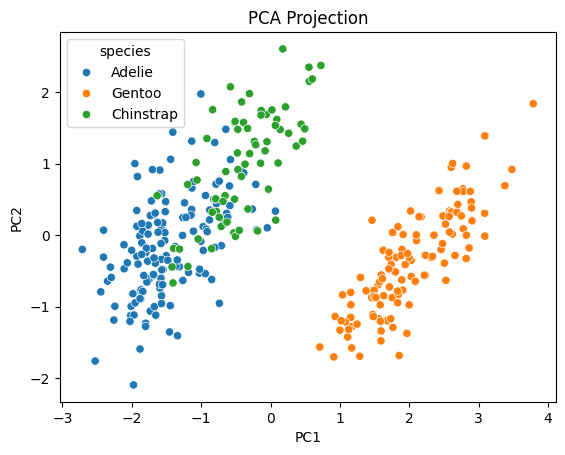

In [ ]:
# Plot pca results
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['species'] = y.values

sns.scatterplot(pca_df, x='PC1', y='PC2', hue='species')
plt.title("PCA Projection")
plt.show()

In [ ]:
# Apply t-SNE

# t-SNE with 2 components
tsne = TSNE(n_components=2)

# Transform data
X_tsne = tsne.fit_transform(X_standardized)

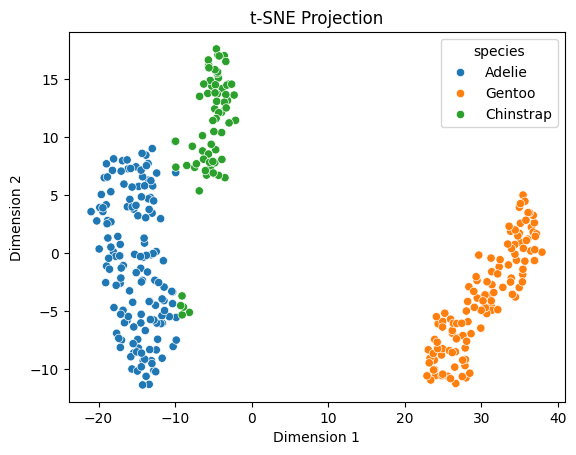

In [ ]:
# Plot tsne results
tsne_df = pd.DataFrame(X_tsne, columns=['Dimension 1', 'Dimension 2'])
tsne_df['species'] = y.values

sns.scatterplot(tsne_df, x='Dimension 1', y='Dimension 2', hue='species')
plt.title("t-SNE Projection")
plt.show()

In [ ]:
# Apply UMAP

# UMAP with 2 components
reducer = umap.UMAP(n_components=2)

# Transform data
X_umap = reducer.fit_transform(X_standardized)

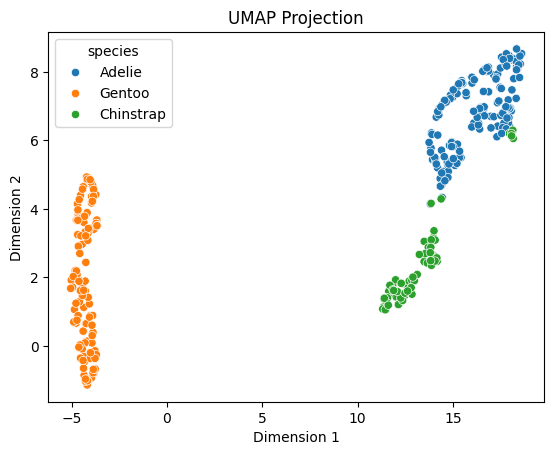

In [ ]:
# Plot umap results
umap_df = pd.DataFrame(X_umap, columns=['Dimension 1', 'Dimension 2'])
umap_df['species'] = y.values

sns.scatterplot(umap_df, x='Dimension 1', y='Dimension 2', hue='species')
plt.title("UMAP Projection")
plt.show()

c. Analyze the resulting plots and describe the main patterns you observe.

- Which method produces the most visually separable clusters?
- Are there any species that overlap in one method but not in others?
- What might explain these differences in how the data is projected?

Elaborate on your observations and compare the strengths and limitations of each method based on this toy example.


The plots above reveal similarities in how the three dimension reduction methods treated the data. All three methods successfully created a distinct cluster for the Gentoo species. However, the Adelie and Chinstrap species were plotted much closer together and have a slight amount of overlap.

Both the t-SNE and UMAP methods produced equally separable clusters, based on a visual analysis of the plots. PCA performed the worst at separating the Adelie and Chinstrap species as there is a significant amount of overlap between the two. It appears that a few outlier Chinstrap penguins are classified in the Adelie area in both UMAP and t-SNE.

PCA may appear the most different of the three methods because it captures the maximum variance in the data but is not effective at determining non-linear relationships. t-SNE and UMAP are similar because they consider each point by mapping them to neighbors and are better handling nonlinear data. One limitation for UMAP is that the simple code chunk of fitting and transforming took 23 seconds, which I found unexpected because UMAP is commended for being fast. Also, the penguins dataset is small and has only four dimensions, so the dimensionality reduction abilities of t-SNE and UMAP have not fully come into play yet.

d. For **t-SNE** and **UMAP**, explore how different hyperparameter settings affect the resulting 2D projections.

- For **t-SNE**, vary the `perplexity` parameter (e.g., 5, 30, 50).
- For **UMAP**, vary the `n_neighbors` parameter (e.g., 5, 15, 50) and optionally `min_dist`.

For each configuration:
- Plot the resulting 2D projection.
- Use color to represent species.

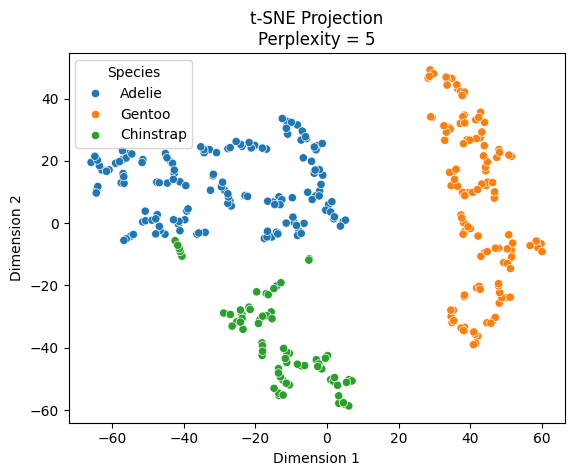

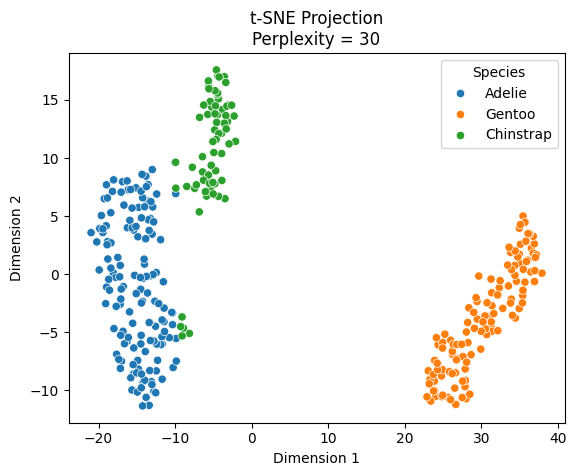

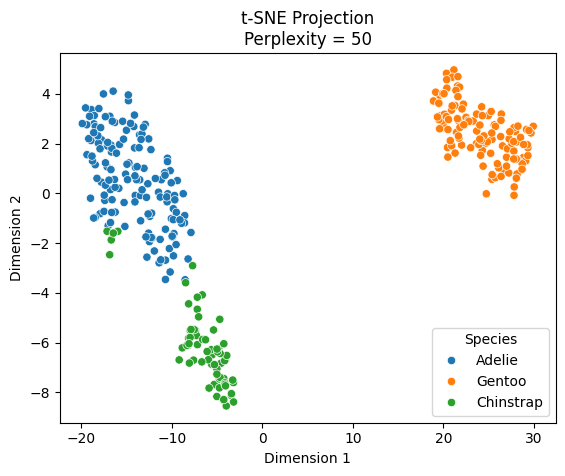

In [ ]:
# Vary t-SNE the perplexity parameter and plot results
perplexity = [5, 30, 50]

for p in perplexity:
  tsne = TSNE(n_components=2, perplexity=p)
  X_tsne = tsne.fit_transform(X_standardized)

  tsne_df = pd.DataFrame(X_tsne, columns=['Dimension 1', 'Dimension 2'])
  tsne_df['Species'] = y.values

  sns.scatterplot(tsne_df, x="Dimension 1", y="Dimension 2", hue="Species")
  plt.title(f"t-SNE Projection\nPerplexity = {p}")
  plt.show()


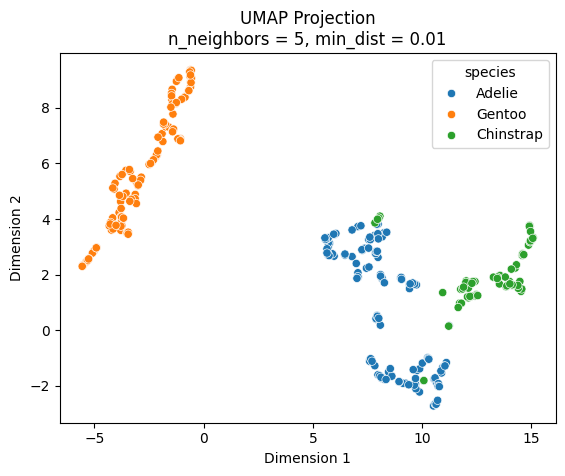

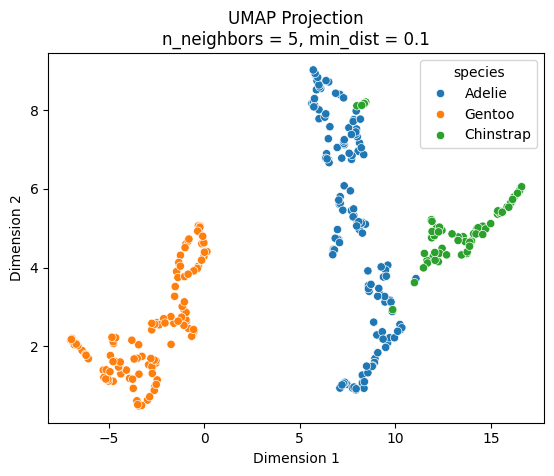

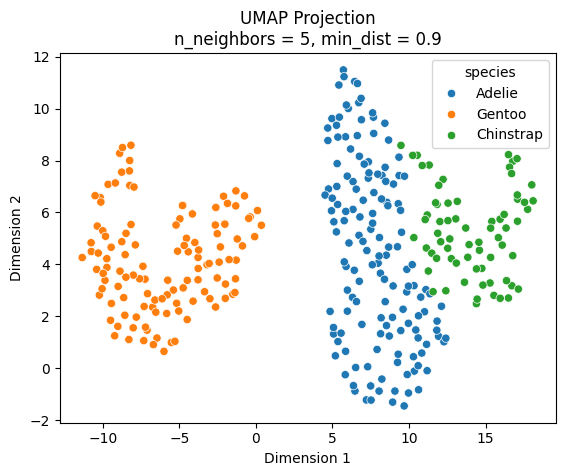

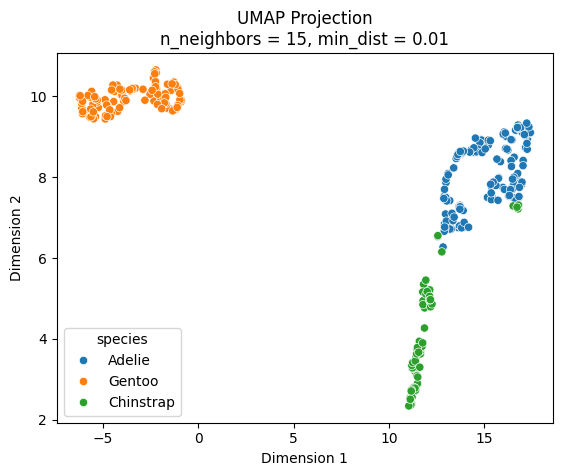

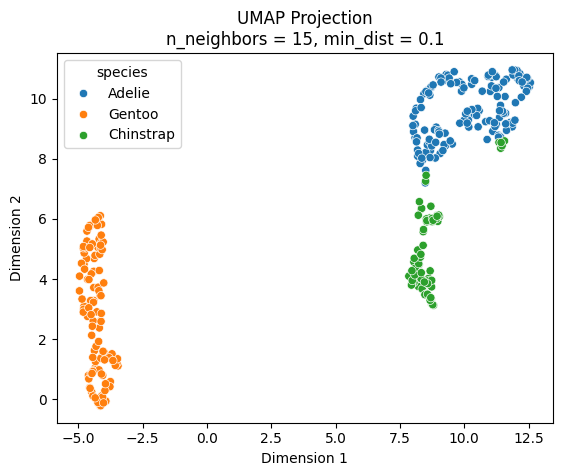

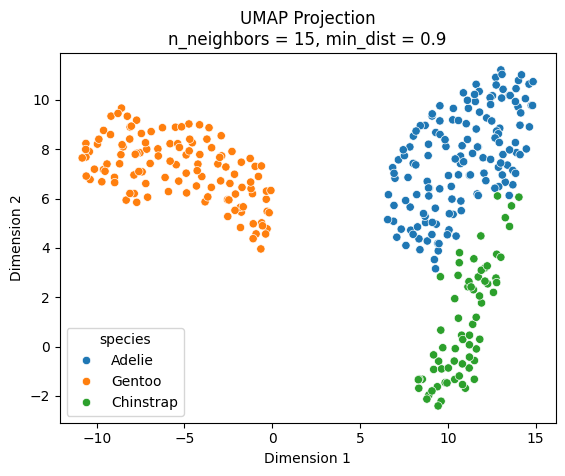

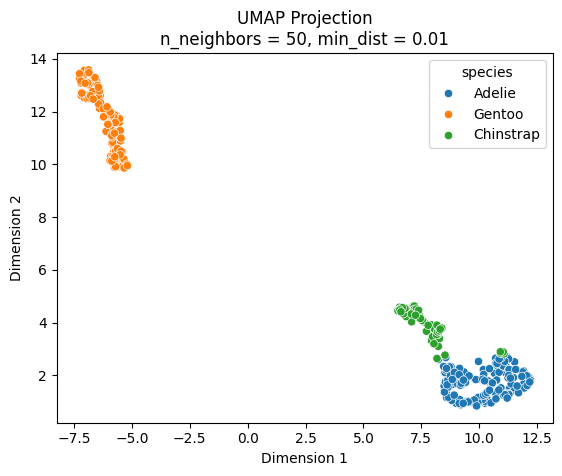

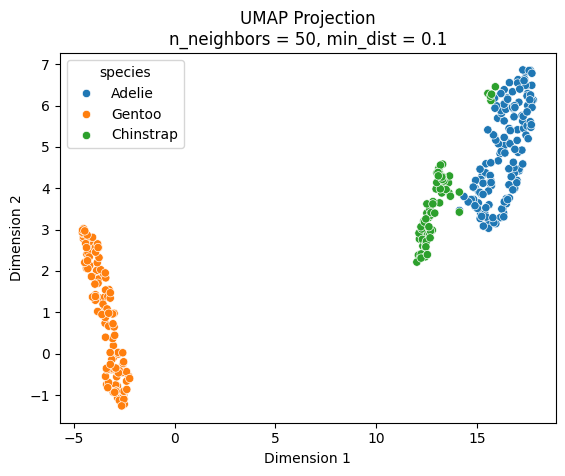

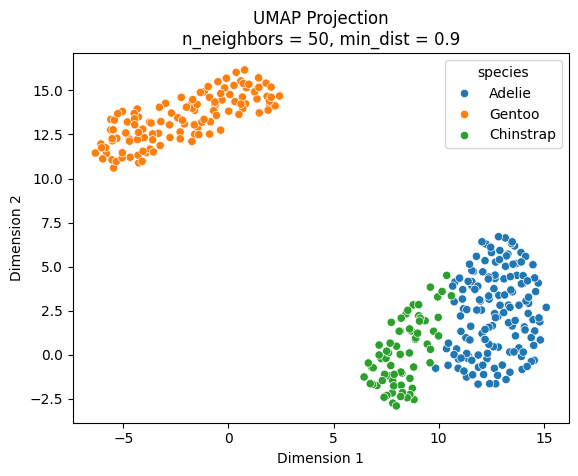

In [ ]:
# Vary UMAP n_neighbors and min_dist parameters and plot results
n_neighbors = [5, 15, 50]
min_dist = [0.01, 0.1, 0.9]

for n in n_neighbors:
  for d in min_dist:
    reducer = umap.UMAP(n_components=2, n_neighbors=n, min_dist=d)
    X_umap = reducer.fit_transform(X_standardized)

    umap_df = pd.DataFrame(X_umap, columns=['Dimension 1', 'Dimension 2'])
    umap_df['species'] = y.values

    sns.scatterplot(umap_df, x='Dimension 1', y='Dimension 2', hue='species')
    plt.title(f"UMAP Projection\nn_neighbors = {n}, min_dist = {d}")
    plt.show()


After generating the plots, describe the main changes you observe in the visualizations:
- How do the clusters shift, stretch, or separate as hyperparameters change?
- Which settings appear to better preserve the structure of the data?

Elaborate on your observations and support your discussion with specific visual examples.

### t-SNE Modifications
A larger perplexity value in t-SNE leads to a better distribution of observations. When perplexity is set to 5 (the lowest option), the data points are sparse and grouped together in subclusters even within their own species. This option does not maintain the structure of the data in a visually appealing way. There is not a distinct difference between the plots when perplexity is set to 30 and 50, but they both do well at preserving the structure of the data.

### UMAP Modifications
By increasing the number of neighbors used by UMAP, the data becomes more tightly grouped together for each species. In contrast, increasing the min distance makes the data more spread out among its clusters. When min_dist is set to 0.9, the resulting scatterplot is the most visually appealing, with evenly dispersed data within clusters and smooth ovular shapes for each species. The min_dist setting also separates the Adelie and Chinstrap species when it is set to 0.9, better than any of the previous models including PCA and t-SNE.

## 3. Apply to Real Data (1000 Genomes Subset) (25 points) (DJ)

Your goal in this section is to **try to create a figure similar to Figure 1** of the Diaz-Papkovich *et al.* (2019) paper, using a subset of genotype data from the **1000 Genomes Project**.

To do so, complete the following steps:

a. **Download and load the dataset.**  
You can find the genotype data here:  
https://github.com/UVADS/DS-4021/blob/205ec2f2fb986f5e9db863409bed94a54b9da72d/datasets/genome_data_lab4.npy  
Each row corresponds to an individual, and each column to a genetic variant.  

Population labels for each individual can be found here:  
https://github.com/UVADS/DS-4021/blob/205ec2f2fb986f5e9db863409bed94a54b9da72d/datasets/population_labels_lab4.txt

b. **Standardize** the features (i.e., transform the genotype values to have zero mean and unit variance).

c. Apply **PCA**, **t-SNE**, and **UMAP** to reduce the data to 2 dimensions.

d. Create **scatter plots** of the resulting projections, coloring each point according to its **population group**.

e. Reflect on the following questions:
- Which method provides the best visual separation of global population groups?
- What changes if you first reduce the data to the **top 25 PCA components**, and then apply t-SNE or UMAP?
- What are the trade-offs between **interpretability** and **performance** when using these dimensionality reduction methods?

Please elaborate on your answers and use the plots to support your discussion.

In [2]:
#Part A
import requests
from io import BytesIO

url = "https://github.com/UVADS/DS-4021/raw/205ec2f2fb986f5e9db863409bed94a54b9da72d/datasets/genome_data_lab4.npy"

response = requests.get(url)
response.raise_for_status()

data = np.load(BytesIO(response.content), allow_pickle=True)

X_2 = pd.DataFrame(data)
print(X_2.head())

   0    1    2    3    4    5    6    7    8    9    ...  858  859  860  861  \
0    0    1    1    2    1    1    2    1    0    0  ...    0    0    0    0   
1    0    1    2    1    0    1    1    2    0    0  ...    0    0    0    0   
2    0    2    1    0    1    0    2    2    1    0  ...    0    0    0    0   
3    2    2    1    1    0    2    2    2    1    0  ...    0    0    1    0   
4    1    2    1    0    0    0    0    2    0    0  ...    0    0    0    0   

   862  863  864  865  866  867  
0    2    0    0    2    0    1  
1    2    0    0    1    0    1  
2    2    0    2    0    0    1  
3    1    0    0    0    0    1  
4    2    0    1    0    0    2  

[5 rows x 868 columns]


In [3]:
url_y = "https://raw.githubusercontent.com/UVADS/DS-4021/205ec2f2fb986f5e9db863409bed94a54b9da72d/datasets/population_labels_lab4.txt"
y_2 = np.loadtxt(url_y, dtype = str)

In [4]:
y_2 = np.array(y_2).ravel()
print(np.unique(y_2))

['ACB' 'ASW' 'BEB' 'CDX' 'CEU' 'CHB' 'CHS' 'CLM' 'ESN' 'FIN' 'GBR' 'GIH'
 'GWD' 'IBS' 'ITU' 'JPT' 'KHV' 'LWK' 'MSL' 'MXL' 'PEL' 'PJL' 'PUR' 'STU'
 'TSI' 'YRI']


In [5]:
#Part B
scaler = StandardScaler()
X_2_scaled = scaler.fit_transform(X_2)
X_2_scaled = pd.DataFrame(X_2_scaled, columns=X_2.columns)

In [6]:
mean = X_2_scaled.mean(axis = 0)
std = X_2_scaled.std(axis = 0)

print(f"Mean (first 5 cols): {mean[:5]}")
print(f"Std  (first 5 cols): {std[:5]}")

Mean (first 5 cols): 0    1.235726e-16
1    0.000000e+00
2    1.647635e-17
3    8.238177e-17
4   -4.119088e-18
dtype: float64
Std  (first 5 cols): 0    1.000145
1    1.000145
2    1.000145
3    1.000145
4    1.000145
dtype: float64


In [7]:
# Apply PCA

# PCA with 2 componenets
pca = PCA(n_components=2)

# Obtain principal components
X_2_pca = pca.fit_transform(X_2_scaled)

In [8]:
df_pca = pd.DataFrame({
    'PC1': X_2_pca[:, 0],
    'PC2': X_2_pca[:, 1],
    'Population': y_2
})

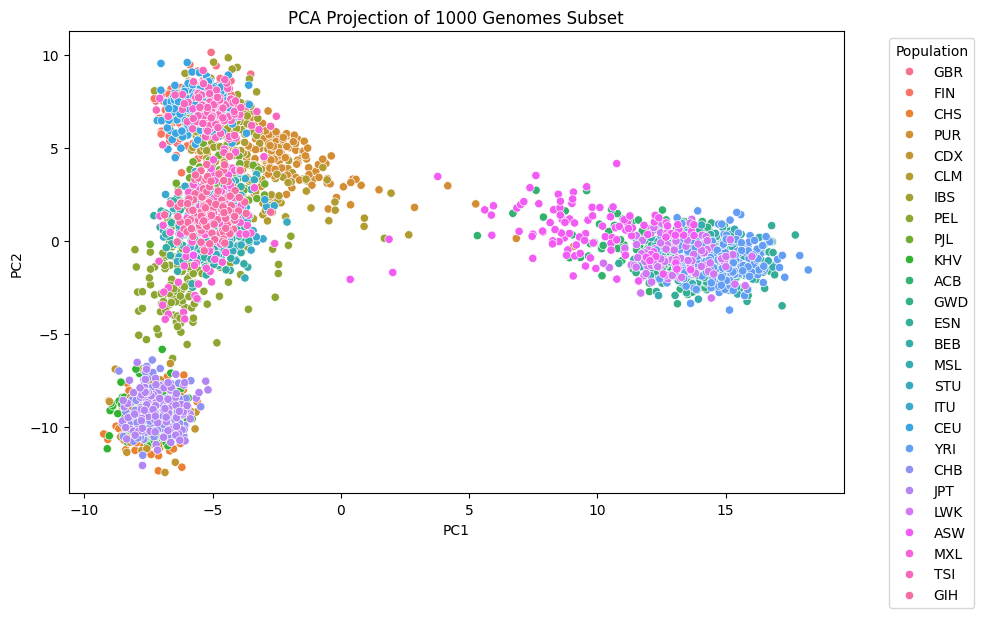

In [9]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='Population')
plt.legend(title='Population', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('PCA Projection of 1000 Genomes Subset')
plt.show()

In [10]:
#Apply t-SNE

# t-SNE with 2 components
tsne = TSNE(n_components=2)

# Transform data
X_2_tsne = tsne.fit_transform(X_2_scaled)

df_tsne = pd.DataFrame({
    'TSNE1': X_2_tsne[:, 0],
    'TSNE2': X_2_tsne[:, 1],
    'Population': y_2
})

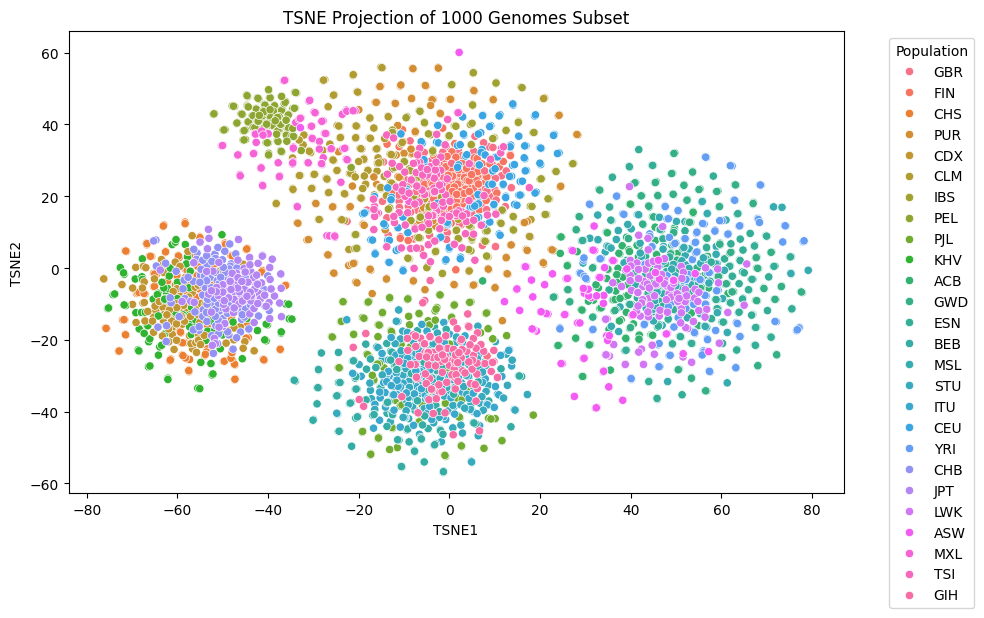

In [11]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_tsne, x='TSNE1', y='TSNE2', hue='Population')
plt.legend(title='Population', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('TSNE Projection of 1000 Genomes Subset')
plt.show()

In [12]:
# Apply UMAP

# UMAP with 2 components
reducer = umap.UMAP(n_components=2)

# Transform data
X_2_umap = reducer.fit_transform(X_2_scaled)

df_umap = pd.DataFrame({
    'UMAP 1': X_2_umap[:, 0],
    'UMAP 2': X_2_umap[:, 1],
    'Population': y_2
})

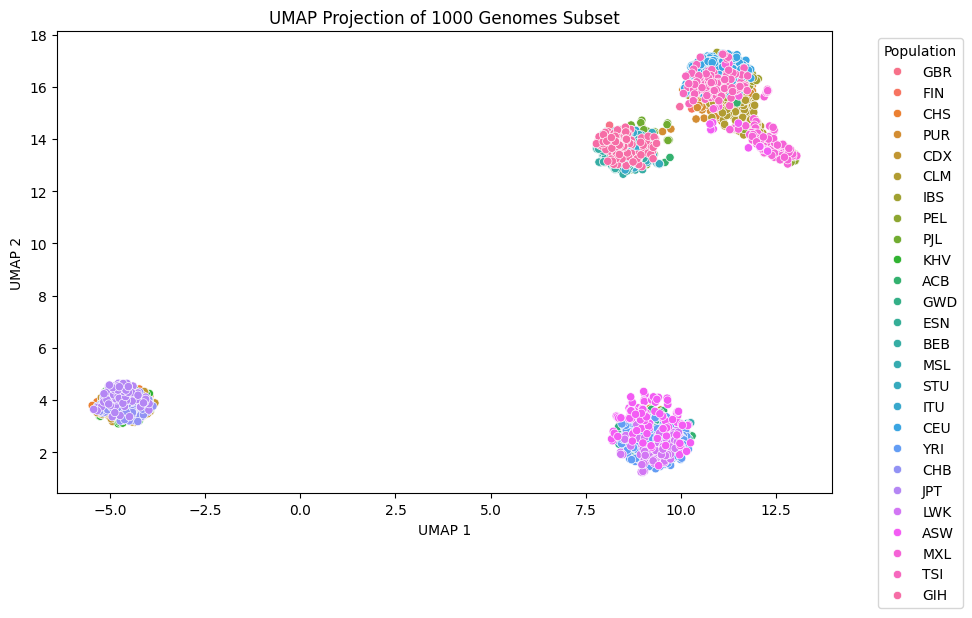

In [13]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_umap, x='UMAP 1', y='UMAP 2', hue='Population')
plt.legend(title='Population', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('UMAP Projection of 1000 Genomes Subset')
plt.show()

e. Reflect on the following questions:

* Which method provides the best visual separation of global population groups?
* What changes if you first reduce the data to the top 25 PCA components, and then apply t-SNE or UMAP?
* What are the trade-offs between interpretability and performance when using these dimensionality reduction methods?

I believe that UMAP provides the best visual separation of global population groups as it generates well separated clusters in the 2D project compared to PCA or t-SNE. UMAP tends to preserve both local and global structure making it efficient to distinguish the population groups.

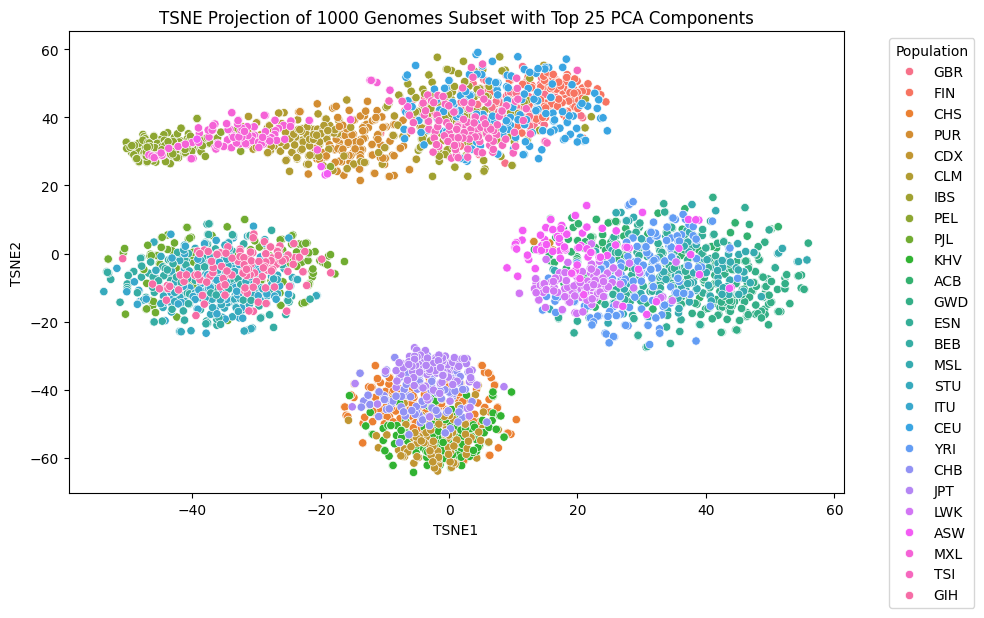

In [14]:
pca = PCA(n_components = 25)
PCA_25 = pca.fit_transform(X_2_scaled)

tsne_25 = TSNE(n_components=2, random_state=42)
X_25_tsne = tsne_25.fit_transform(PCA_25)

df_25_tsne = pd.DataFrame({
    'TSNE1': X_25_tsne[:, 0],
    'TSNE2': X_25_tsne[:, 1],
    'Population': y_2
})

plt.figure(figsize=(10,6))
sns.scatterplot(data=df_25_tsne, x='TSNE1', y='TSNE2', hue='Population')
plt.legend(title='Population', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('TSNE Projection of 1000 Genomes Subset with Top 25 PCA Components')
plt.show()

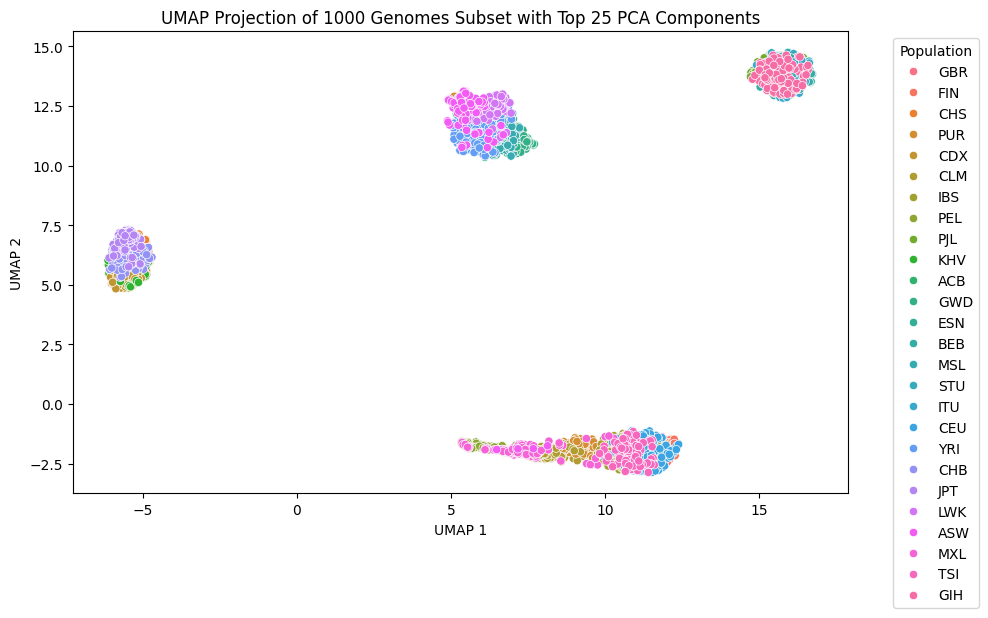

In [15]:
pca = PCA(n_components = 25)
PCA_25 = pca.fit_transform(X_2_scaled)
reducer_25 = umap.UMAP(n_components=2)
X_25_umap = reducer_25.fit_transform(PCA_25)

df_25_umap = pd.DataFrame({
    'UMAP 1': X_25_umap[:, 0],
    'UMAP 2': X_25_umap[:, 1],
    'Population': y_2
})

plt.figure(figsize=(10,6))
sns.scatterplot(data=df_25_umap, x='UMAP 1', y='UMAP 2', hue='Population')
plt.legend(title='Population', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('UMAP Projection of 1000 Genomes Subset with Top 25 PCA Components')
plt.show()

By reducing the data into top 25 components, we were able to reduce the noise and redundant data. Furthermore, t-SNE and UMAP is computationally expensive; however, by reducing the data into top 25 components, the speed is going to be faster. Furthermore, as shown in the visualizations above, the clusters for both t-SNE and UMAP is more well-separated with the reduced dimensions.

* PCA performs well when the components are linear. PCA is computationally efficient even for large datasets. However, PCA only captures linear relationships well and performs poorly when capturing non-linear relationships.
* t-SNE performs well to visualize local clusters in more complex data, but it is computationally expensive. Furthermore, t-SNE does not preserve global structure well and axes have no meaning so it is hard to interpret.
* UMAP balances local and global structure preservation better than t-SNE, and is more faster and scalable. It is also a great choice for visualization. UMAP will perform poorly than PCA for linear data, as UMAP is optimized for non-linear data.

## 4. Collaboration Reflection (5 points) (DJ)

As a group, briefly reflect on the following (max 1–2 short paragraphs):

- How did the group dynamics work throughout the assignment?
- Were there any major disagreements or diverging approaches?
- How did you resolve conflicts or make final modeling decisions?
- What did you learn from each other during this project?

Unlike last week all of my groupmates started this lab early as Kayla and Mason finished off the first two parts until Saturday. I don't think we had any disagreements. As I was completing Part 3, I felt it very easy to continue from where they left as Kayla's explanation of t-SNE and UMAP was very easy to understand, as well as Mason's code as it was very readable. I learned that all of my groupmates don't procrastinate and are hard working.